# Tarea #1 - Ciencia de Redes (ICD5167- OII467 2026-1)
**Profesor:** Wenceslao Palma

**Alumna:** Antonia Luengo - 21.377.578-2

## Problema 1: Experimentos con el modelo Erdős-Rényi $G_{n,p}$.

En el modelo Erdős-Rényi, cada par de nodos se une a través de una arista con una probabilidad $p$. Considere un conjunto de nodos $V$ de tamaño $n = 100$. Considere 100 valores para $p$ entre 0 y 1.

In [7]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

### 1(a) - Implementación del modelo $G_{n,p}$ y recolección de métricas


In [8]:
n = 100
p_values = np.linspace(0, 1, 100)
num_iterations = 30  # Tolerancia estocastica

avg_num_cc = []
avg_largest_cc_size = []
avg_shortest_path = []
avg_density = []
avg_clustering = []

for p in p_values:
    num_cc_iter = []
    largest_cc_size_iter = []
    shortest_path_iter = []
    density_iter = []
    clustering_iter = []
    
    for _ in range(num_iterations):
        G = nx.erdos_renyi_graph(n, p)
        
        num_cc = nx.number_connected_components(G)
        num_cc_iter.append(num_cc)
        
        if num_cc > 0:
            largest_cc_nodes = max(nx.connected_components(G), key=len)
            largest_cc_size_iter.append(len(largest_cc_nodes))
            
            largest_cc = G.subgraph(largest_cc_nodes)
            if len(largest_cc) > 1:
                sp = nx.average_shortest_path_length(largest_cc)
            else:
                sp = 0
            shortest_path_iter.append(sp)
        else:
            largest_cc_size_iter.append(0)
            shortest_path_iter.append(0)
            
        density_iter.append(nx.density(G))
        clustering_iter.append(nx.average_clustering(G))
        
    avg_num_cc.append(np.mean(num_cc_iter))
    avg_largest_cc_size.append(np.mean(largest_cc_size_iter))
    avg_shortest_path.append(np.mean(shortest_path_iter))
    avg_density.append(np.mean(density_iter))
    avg_clustering.append(np.mean(clustering_iter))

### 1(b) - Visualización de grafos en diferentes regímenes

Al fijar diferentes probabilidades podemos atravesar los regímenes críticos teóricos donde $\langle k \rangle = p(n-1)$:

1. **Poco Conectado ($p = 0.005$)**: $\langle k \rangle < 1$.
2. **Medianamente poco conectado ($p = 0.01$)**: $\langle k \rangle \approx 1$. 
3. **Medianamente Conectado ($p = 0.03$)**: $\langle k \rangle > 1$ pero $\langle k \rangle < \ln(n)$.
4. **Totalmente Conectado ($p = 0.1$)**: $\langle k \rangle > \ln(n)$. 


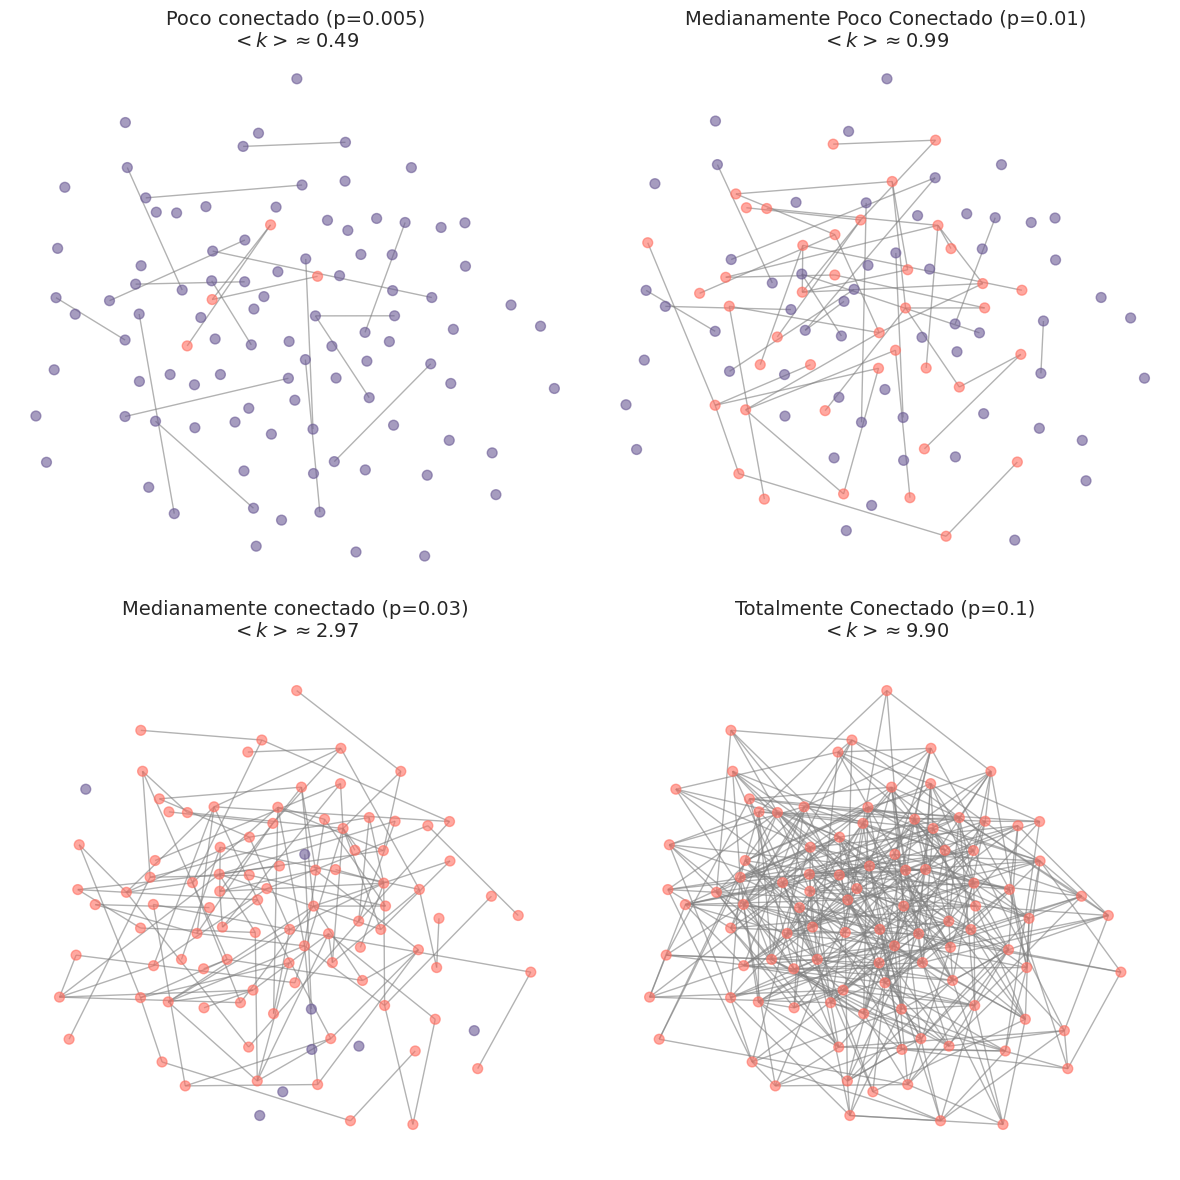

In [9]:
p_viz = [0.005, 0.01, 0.03, 0.1]
titles = [
    f"Poco conectado (p={p_viz[0]})\n$<k> \\approx {p_viz[0]*99:.2f}$",
    f"Medianamente Poco Conectado (p={p_viz[1]})\n$<k> \\approx {p_viz[1]*99:.2f}$",
    f"Medianamente conectado (p={p_viz[2]})\n$<k> \\approx {p_viz[2]*99:.2f}$",
    f"Totalmente Conectado (p={p_viz[3]})\n$<k> \\approx {p_viz[3]*99:.2f}$"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

# Fijo layout usando el régimen conectado para mantener estabilidad espacial entre plots
G_base = nx.erdos_renyi_graph(n, p_viz[-1], seed=42)
pos_fija = nx.spring_layout(G_base, seed=42)

for ax, p, title in zip(axes, p_viz, titles):
    # Mismo seed estricto para fijar los nodos internamente de manera estructural
    G_viz = nx.erdos_renyi_graph(n, p, seed=42)
    if len(G_viz.nodes) > 0:
        largest_cc = max(nx.connected_components(G_viz), key=len)
        node_colors = ['#FF6F61' if node in largest_cc else '#6B5B95' for node in G_viz.nodes()]
    else:
        node_colors = '#6B5B95'
        
    nx.draw(G_viz, pos_fija, ax=ax, node_color=node_colors, node_size=50, edge_color="gray", alpha=0.6)
    ax.set_title(title, fontsize=14)

plt.tight_layout()
plt.show()


### 1(c) - Cálculo y Gráficos Exploratorios

Gráficos sobre el rango $p \in [0, 1]$, y un respectivo zoom iterativo en $p \in [0, 0.1]$ para notar el comportamiento brusco en las franjas analíticas.


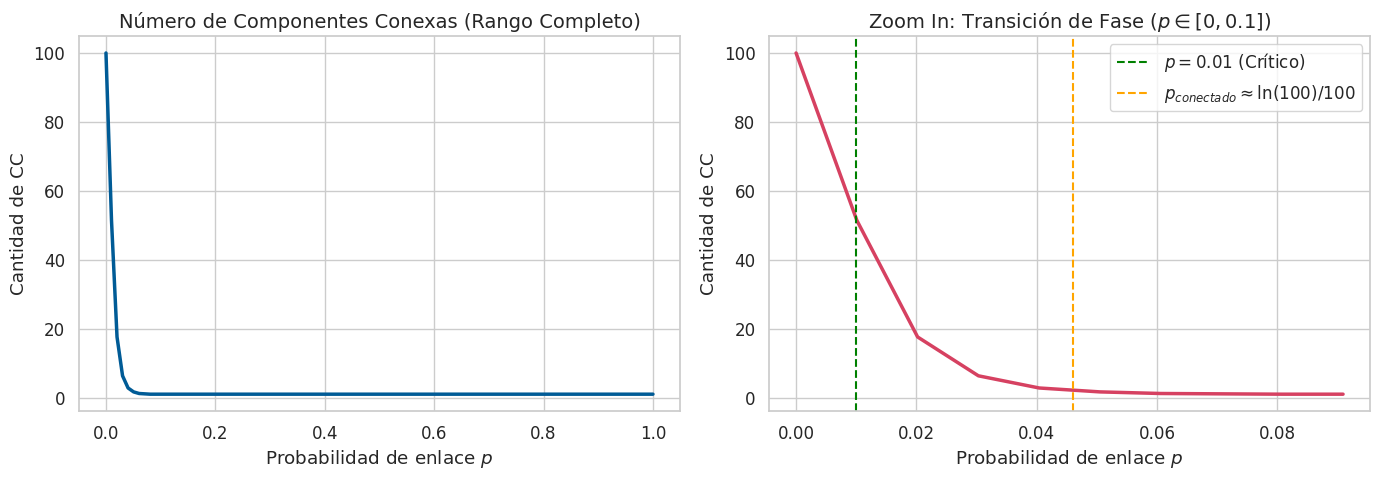

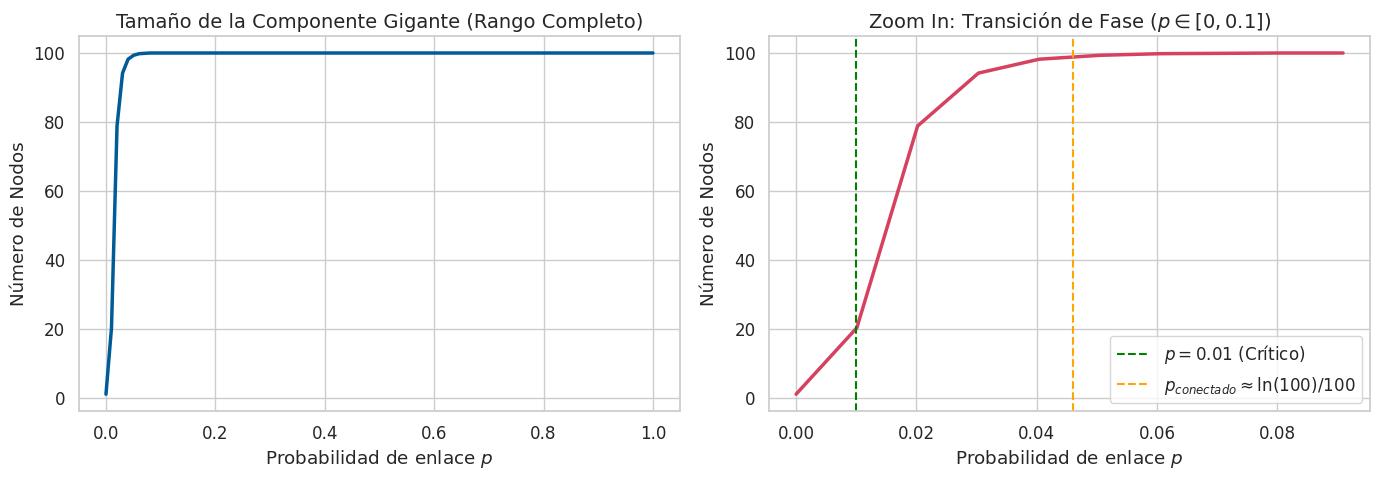

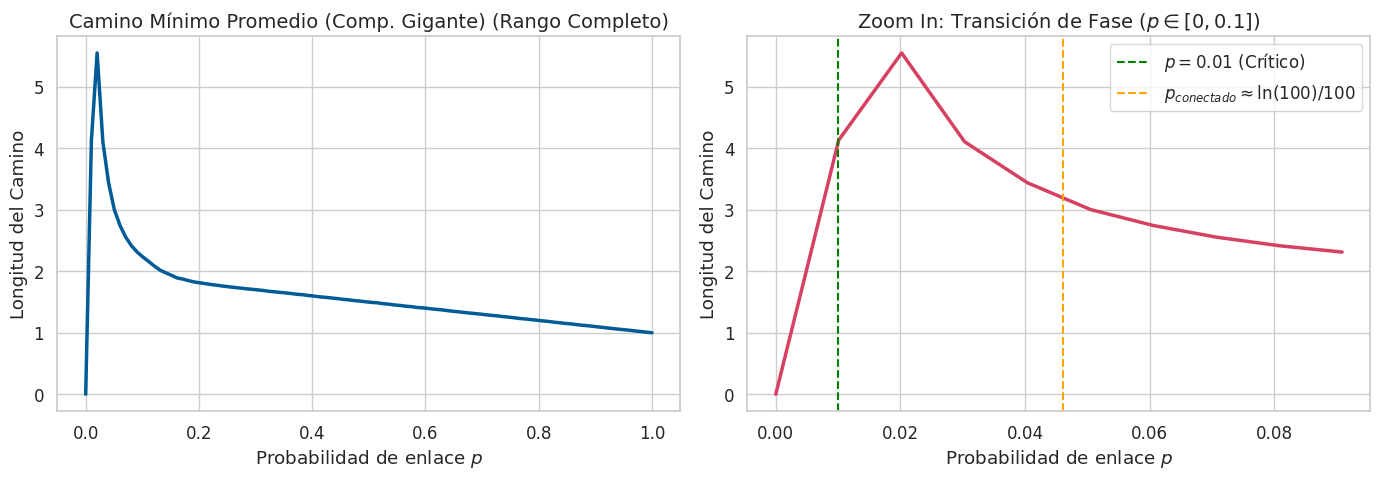

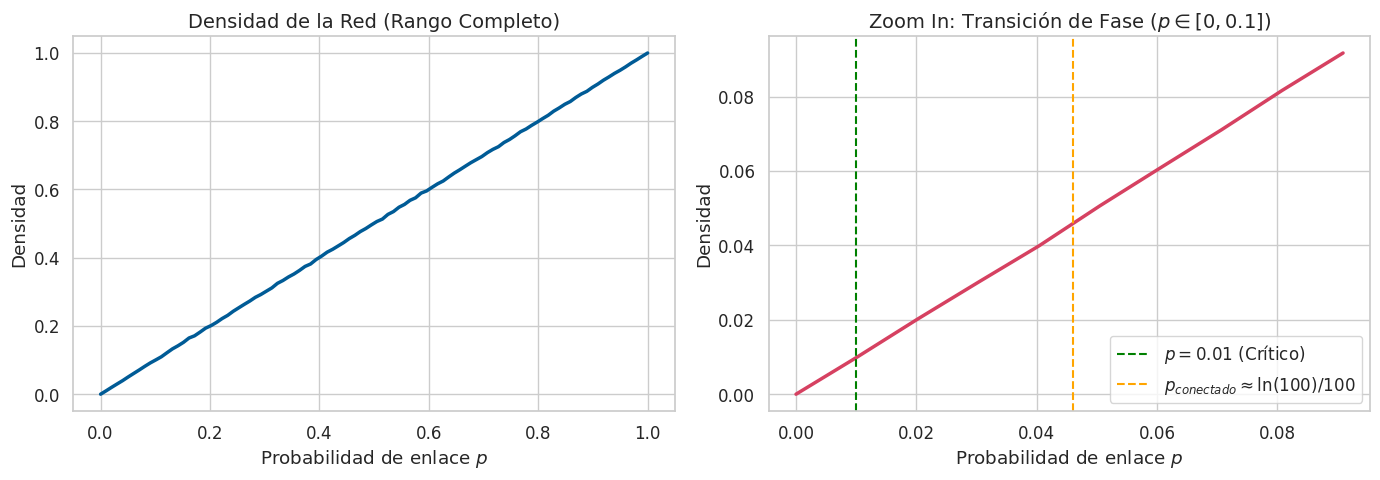

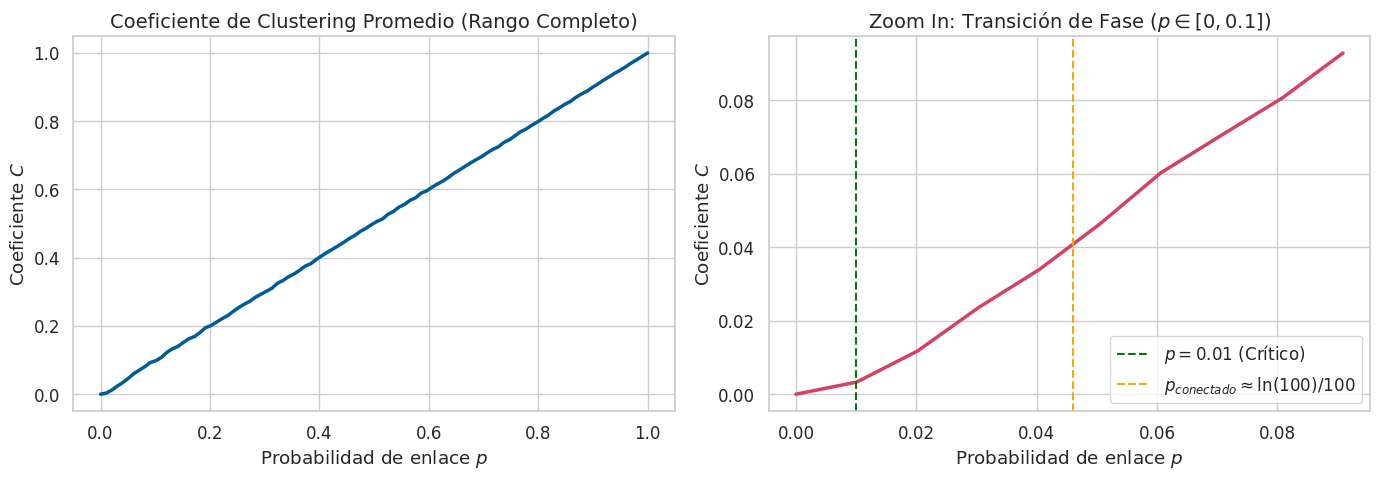

In [10]:
def plot_metric(p_values, metric_values, title, ylabel, show_zoom=True):
    fig, axes = plt.subplots(1, 2 if show_zoom else 1, figsize=(14 if show_zoom else 7, 5))
    
    if not show_zoom:
        axes = [axes]
        
    sns.lineplot(x=p_values, y=metric_values, ax=axes[0], color="#005b96", linewidth=2.5)
    axes[0].set_title(f"{title} (Rango Completo)", fontsize=14)
    axes[0].set_xlabel("Probabilidad de enlace $p$")
    axes[0].set_ylabel(ylabel)
    
    if show_zoom:
        zoom_mask = p_values <= 0.1
        sns.lineplot(x=p_values[zoom_mask], y=np.array(metric_values)[zoom_mask], ax=axes[1], color="#d64161", linewidth=2.5)
        axes[1].axvline(x=0.01, color='green', linestyle='--', label='$p=0.01$ (Crítico)')
        axes[1].axvline(x=np.log(n)/n, color='orange', linestyle='--', label='$p_{conectado} \\approx \\ln(100)/100$')
        axes[1].set_title(f"Zoom In: Transición de Fase ($p \\in [0, 0.1]$)", fontsize=14)
        axes[1].set_xlabel("Probabilidad de enlace $p$")
        axes[1].set_ylabel(ylabel)
        axes[1].legend()

    plt.tight_layout()
    plt.show()

# Despliegue de gráficos
plot_metric(p_values, avg_num_cc, "Número de Componentes Conexas", "Cantidad de CC", show_zoom=True)
plot_metric(p_values, avg_largest_cc_size, "Tamaño de la Componente Gigante", "Número de Nodos", show_zoom=True)
plot_metric(p_values, avg_shortest_path, "Camino Mínimo Promedio (Comp. Gigante)", "Longitud del Camino", show_zoom=True)
plot_metric(p_values, avg_density, "Densidad de la Red", "Densidad", show_zoom=True)
plot_metric(p_values, avg_clustering, "Coeficiente de Clustering Promedio", "Coeficiente $C$", show_zoom=True)


### 1(c.6) - Conclusiones
El comportamiento analizado con las métricas refleja exactamente lo estudiado en la teoría para el modelo Erdos-Rényi:

1. Se nota claramente como al pasar el umbral de p = 0.01 hay un cambio abrupto, en el que la mayoria de los nodos sueltos se unen formando el gran grupo central. Luego, al alcanzar el umbral $p_{conectado} \approx \ln(100)/100 \approx 0.046$, la componente gigante se empieza a volver totalmente conectada, desapareciendo los nodos aislados.

2. Tambien se observa como el camino minimo promedio alcanza su punto más alto pasando el punto crítico. Esto se debe a que al empezar a formarse el componente gigante, cada vez aparecen mas posibles caminos para conectar un nodo y otro.

3. La densidad y el coeficiente de clustering crecen en linea recta, ya que la probabilidad de que dos vecinos esten conectados entre si (probabilidad de crear un enlace) es directamente proporcional a p.

## Problema 2: Erdos-Rényi $G_{n,p}$ y los valores de $k_{min}$ y $k_{max}$


### 1. Desarrollo Teórico

En una red aleatoria, la distribución de grados $p_k$ equivale en el límite de un $N$ grande a la distribución de Poisson:

$$ p_k = e^{-\langle k \rangle} \frac{\langle k \rangle^k}{k!} $$

El grado máximo $k_{max}$ se define como aquel en el cual esperamos que como máximo exista **solo un nodo** en toda la red con dicho grado. Matemáticamente esto se expresa condicionando su probabilidad a la inversa del tamaño de la red:

$$ N \cdot p_{k_{max}} \approx 1 \implies p_{k_{max}} \approx \frac{1}{N} $$

Sustituyendo la ecuación de Poisson:

$$ e^{-\langle k \rangle} \frac{\langle k \rangle^{k_{max}}}{k_{max}!} = \frac{1}{N} $$

Aplicando logaritmo natural a ambos lados de la ecuación:

$$ -\langle k \rangle + k_{max} \ln \langle k \rangle - \ln(k_{max}!) = -\ln N $$

Usando la aproximación de Stirling para el término del factorial ($\ln(x!) \approx x \ln x - x$), obtenemos:

$$ -\langle k \rangle + k_{max} \ln \langle k \rangle - k_{max} \ln(k_{max}) + k_{max} = -\ln N $$

$$ k_{max} \ln \left( \frac{\langle k \rangle e}{k_{max}} \right) = \langle k \rangle - \ln N $$

Con esta dependencia, a medida que $N$ aumenta, el crecimiento logarítmico dicta que tanto $k_{max}$ como $k_{min}$ (bajo la misma lógica $P(k_{min}) \approx 1/N$) se modificarán o expandirán apenas logarítmicamente $O(\ln N)$, manteniéndose sumamente restringidos pese al tamaño desproporcionado o inmenso de la red.

### 2. Generación, Cálculo Numérico y Tabulación

In [11]:
import pandas as pd
from scipy.stats import poisson

N_values = [10000, 20000, 50000]
k_avg = 50

resultados = []

for N in N_values:
    p = k_avg / (N - 1)
    
    # Generar la red grande con memoria optimizada
    G = nx.fast_gnp_random_graph(N, p, seed=42)
    
    # Valores Empíricos
    grados = [d for _, d in G.degree()]
    k_min_emp = min(grados)
    k_max_emp = max(grados)
    
    # Valores Teóricos usando PPF (1/N inferior) y ISF (1/N superior)
    k_min_teo = poisson.ppf(1/N, mu=k_avg)
    k_max_teo = poisson.isf(1/N, mu=k_avg)
    
    resultados.append({
        'Tamaño (N)': N,
        'Prop. p': round(p, 5),
        'k_min (Teórico)': int(k_min_teo),
        'k_min (Empírico)': int(k_min_emp),
        'k_max (Teórico)': int(k_max_teo),
        'k_max (Empírico)': int(k_max_emp)
    })

# Tabular la comparativa
df_comparativa = pd.DataFrame(resultados)
display(df_comparativa)

,Tamaño (N),Prop. p,k_min (Teórico),k_min (Empírico),k_max (Teórico),k_max (Empírico)
0,10000,0.0050,26,24,78,78
1,20000,0.0025,25,26,80,81
2,50000,0.0010,24,24,82,85


## 3. Conclusión: ¿Qué se observa?

Al observar los resultados, se evidencia una coincidencia casi exacta entre el  teórico y el empírico. Podemos observar que aunque el tamaño de la red ($N$) se multiplica por cinco (pasando de 10,000 a 50,000 nodos), el grado máximo empírico ($k_{max}$) apenas crece de 78 a 85. Esto demuestra en la práctica que el modelo aleatorio de Erdos-Rényi carece de hubs masivos. Los grados extremos están fuertemente acotados y crecen de manera extremadamente lenta (en el orden de $\ln N$), confirmando que la conectividad en estas redes sigue una distribución de Poisson que decae rápidamente alrededor del grado promedio.

## Problema 3: Experimentos con una red real


Seleccionamos desde el sitio **Network Repository** tres redes ($G_1$, $G_2$ y $G_3$) pertenecientes a diferentes dominios.

In [ ]:
import networkx as nx #quitar
import numpy as np #quitar
import pandas as pd #quitar
import matplotlib.pyplot as plt #quitar
import seaborn as sns #quitar
import random
import os
from scipy.io import mmread #quitar

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
random.seed(42)

## 3(a) Análisis de Dominios Distintos

### Función de métricas con muestreo estocástico para $\langle l \rangle$

In [ ]:
def calcular_metricas(G, nombre):
    if len(G) == 0:
        return {}
    
    largest_cc = max(nx.connected_components(G), key=len)
    G_gigante = G.subgraph(largest_cc)
    
    # Metricas globales
    grados = [d for _, d in G.degree()]
    k_avg = np.mean(grados)
    sigma_k = np.std(grados)
    
    # Camino minimo promedio (<l>)
    print(f" -> Calculando camino mínimo exacto para {len(G_gigante)} nodos en {nombre}. Esto tomará un rato...")
    l_avg = nx.average_shortest_path_length(G_gigante)
    print(f" -> ¡Listo {nombre}!")
    
    return {
        'Red': nombre,
        'Nodos (N)': G.number_of_nodes(),
        'Aristas (L)': G.number_of_edges(),
        '<k>': round(k_avg, 2),
        '\u03c3_k': round(sigma_k, 2),
        '<l>': round(l_avg, 2)
    }

### Lectura de datos y Tabulación de Métricas (Parte A)

In [ ]:
ruta_a = 'data/redes_reales/parte_a'
archivos_a = os.listdir(ruta_a)

redes_a = []
resultados_a = []

for archivo in archivos_a:
    path_completo = os.path.join(ruta_a, archivo)
    print(f"Cargando {archivo}...")
    
    if archivo.endswith('.edges'):
        G = nx.read_edgelist(path_completo, comments='%', nodetype=int)
    elif archivo.endswith('.mtx'):
        matriz = mmread(path_completo)
        G = nx.Graph(matriz)
    else:
        continue
        
    redes_a.append((archivo, G))
    
    # Calculo metricas
    metricas = calcular_metricas(G, archivo)
    resultados_a.append(metricas)

df_parte_a = pd.DataFrame(resultados_a)
display(df_parte_a)

Cargando bio-yeast-protein-inter.edges...
Cargando socfb-Wisconsin87.mtx...
Cargando road-euroroad.edges...


,Red,Nodos (N),Aristas (L),<k>,σ_k,<l>
0,bio-yeast-protein-inter.edges,1870,2277,2.44,3.16,6.81
1,socfb-Wisconsin87.mtx,23831,835946,70.16,73.06,2.93
2,road-euroroad.edges,1174,1417,2.41,1.19,18.40


### Visualización: Curvas de Distribución de Grados (Log-Binning)
De acuerdo con Barabási, es crucial utilizar escala **Log-Log** y **Log-Binning** (histogramas logarítmicos) para evitar la aparición del "plateau" artificial estocástico en la cola de la distribución.

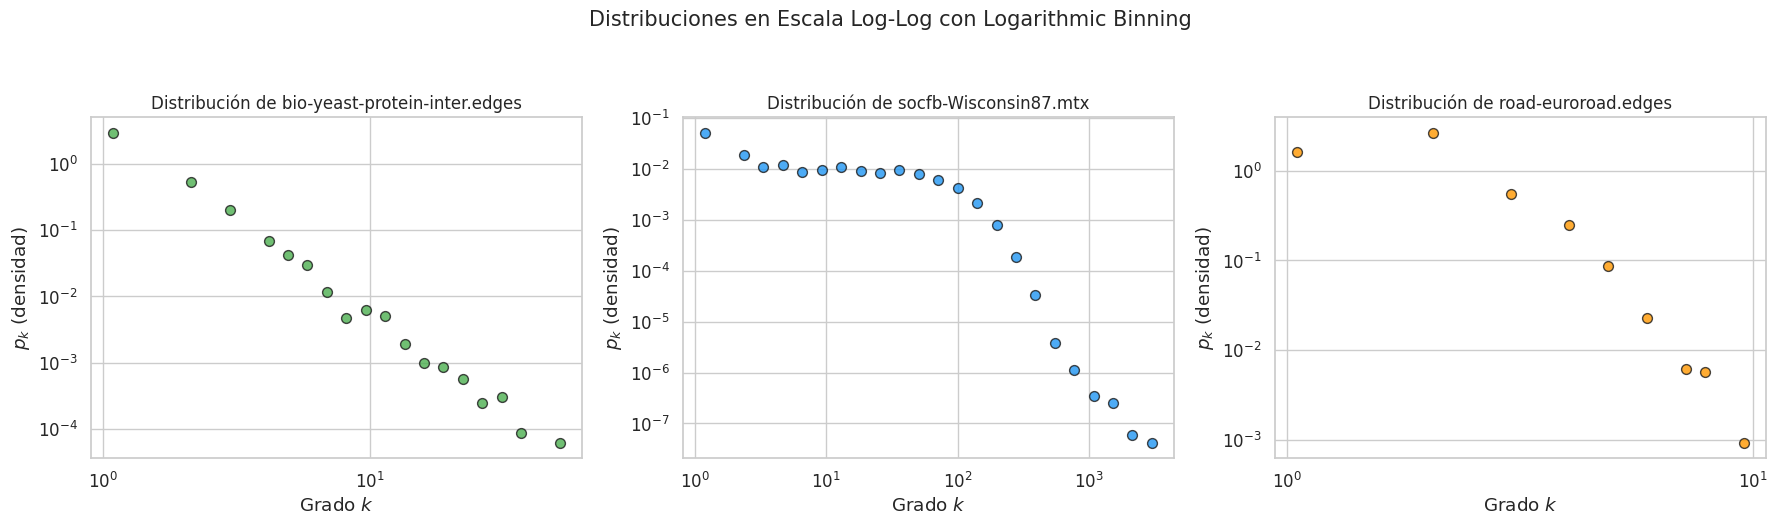

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colores = ['#4CAF50', '#2196F3', '#FF9800']

for i, (nombre, G) in enumerate(redes_a):
    grados = [d for _, d in G.degree()]
    grados = np.array(grados)
    grados = grados[grados > 0] # Evitar log(0)
    
    # Log-Binning con np.logspace
    bins = np.logspace(np.log10(grados.min()), np.log10(grados.max()), 25)
    hist, bin_edges = np.histogram(grados, bins=bins, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Solo graficar bins con densidad mayor a 0
    mask = hist > 0
    
    axes[i].scatter(bin_centers[mask], hist[mask], color=colores[i], s=50, alpha=0.8, edgecolors='k')
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')
    axes[i].set_xlabel('Grado $k$')
    axes[i].set_ylabel('$p_k$ (densidad)')
    axes[i].set_title(f'Distribución de {nombre}', fontsize=12)

plt.suptitle("Distribuciones en Escala Log-Log con Logarithmic Binning", fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

### Conclusión 3(a)

**¿Qué observa? ¿Son redes de libre escala?**

Las redes bio-yeast y Wisconsin87 muestran colas extendidas características de una ley de potencia. Esto confirma empíricamente la existencia de hubs masivos en estos dominios (nodos superando el grado 1000 en la red social).

Por otro lado, road-euroroad cae abruptamente con un grado máximo de $k \approx 10$. Esto demuestra que no es de libre escala; su naturaleza espacial y geográfica impone restricciones físicas severas que prohíben matemáticamente la formación de hubs.

## 3(b) Análisis de un Dominio Común (Redes Facebook Universitarias)
Analizaremos los 4 archivos en el directorio de la **Parte B**, que corresponden al mismo dominio universitario.

In [ ]:
ruta_b = 'data/redes_reales/parte_b'
archivos_b = os.listdir(ruta_b)

redes_b = [] # Lista nueva para guardar los grafos y poder graficarlos
resultados_b = []

for archivo in archivos_b:
    path_completo = os.path.join(ruta_b, archivo)
    print(f"\nCargando {archivo}...")
    
    if archivo.endswith('.mtx'):
        matriz = mmread(path_completo)
        G = nx.Graph(matriz)
        
        redes_b.append((archivo, G)) # Guardamos el grafo para el plot
        
        metricas = calcular_metricas(G, archivo)
        resultados_b.append(metricas)

df_parte_b = pd.DataFrame(resultados_b)
display(df_parte_b)

Cargando y calculando socfb-Amherst41.mtx...
Cargando y calculando socfb-Bowdoin47.mtx...
Cargando y calculando socfb-Bucknell39.mtx...
Cargando y calculando socfb-American75.mtx...


,Red,Nodos (N),Aristas (L),<k>,σ_k,<l>
0,socfb-Amherst41.mtx,2235,90954,81.39,63.31,2.40
1,socfb-Bowdoin47.mtx,2252,84387,74.94,56.64,2.43
2,socfb-Bucknell39.mtx,3826,158864,83.04,59.16,2.50
3,socfb-American75.mtx,6386,217662,68.17,62.04,2.77


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colores_b = ['#e63946', '#1d3557', '#457b9d', '#2a9d8f']

for i, (nombre, G) in enumerate(redes_b):
    grados = [d for _, d in G.degree()]
    grados = np.array(grados)
    grados = grados[grados > 0] # Evitar log(0)
    
    # Log-Binning con np.logspace
    bins = np.logspace(np.log10(grados.min()), np.log10(grados.max()), 25)
    hist, bin_edges = np.histogram(grados, bins=bins, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    mask = hist > 0
    
    axes[i].scatter(bin_centers[mask], hist[mask], color=colores_b[i], s=50, alpha=0.8, edgecolors='k')
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')
    axes[i].set_xlabel('Grado $k$')
    axes[i].set_ylabel('$p_k$ (densidad)')
    axes[i].set_title(f'{nombre}', fontsize=12)

plt.suptitle("Distribuciones en Escala Log-Log (Redes Sociales Parte B)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Conclusión 3(b)

El hallazgo más notable es el bajísimo camino mínimo promedio ($\langle l \rangle$ oscilando entre 2.40 y 2.77). A pesar de que las redes varían sustancialmente en tamaño ($N$ desde 2,235 hasta 6,386 nodos), la distancia social se mantiene muy comprimida. Esto demuestra que cualquier par de estudiantes en estos recintos está separado por menos de 3 grados de conexión.

También, se observa que todas las redes exhiben grados promedio estables ($\langle k \rangle$ entre 68 y 83) y desviaciones estándar altísimas ($\sigma_k \approx 60$). Esta varianza masiva confirma que la dinámica social es universal a través de los campus: se rige por una estructura altamente heterogénea donde unos pocos estudiantes hiperconectados (hubs) actúan como puentes críticos que acortan las distancias globales.